STEP 0: Ensuring Python installed all packages

In terminal, run:
python3 -m pip install torch torchvision torchaudio matplotlib scikit-learn numpy pandas

And to use notebook, run:
python3 -m pip install notebook

then run:
jupyter notebook
To open jupyter, then go to file>new>notebook.
Using Jupyter instead of colab allows you to run blocks and more seamlessly use datasets straight from your computers

The CNN below is for binary classification (2 classes). There are some comments for where you can adjust the code to make it multi-class.

STEP 1: Importing our data

In [1]:
img_height=256
img_width=256

In [2]:
#1.1: Loading necessary add-ins
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# TorchVision
from torchvision import datasets
from torchvision.transforms import v2

# Data utilities
from torch.utils.data import DataLoader, random_split

# Visualisation
import matplotlib.pyplot as plt
import numpy as np

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Miscellaneous
import os
from PIL import Image
import tqdm
import load_data
import architecture
import evaluate

In [3]:
#1.2: Select computing device (most likely CPU)
# Use a GPU if available, otherwise use the CPU
device = torch.device("mps")

print(f"Using device: {device}")

Using device: mps


In [4]:
#1.3: Image transformations definitions
transform = v2.Compose([v2.RandomHorizontalFlip(p=0.5),v2.RandomVerticalFlip(p=0.5), v2.ScaleJitter(target_size=(img_width, img_height), scale_range=(0.7, 1.3)), v2.RandomRotation([0,360]),v2.RandomApply([v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)],0.5), v2.Resize((img_width, img_height)),v2.ToTensor()]) #converts to channel x height x width
#Neural networks require all images to be of the same size before passing them

/opt/anaconda3/envs/GSET/lib/python3.14/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
#1.4: Load dataset to workspace
train_dataset = load_data.Dataset(True, False, False, True, True, False, transform)
test_dataset = load_data.Dataset(False, True, False, True, True, False, transform)
val_dataset = load_data.Dataset(False, False, True, True, True, False, transform)

In [6]:
#1.5: Display data info
print(f"Number of images: {len(train_dataset)}")

Number of images: 2115


0.9882353
1.0
0.972549
0.8666667
1.0
0.9490196


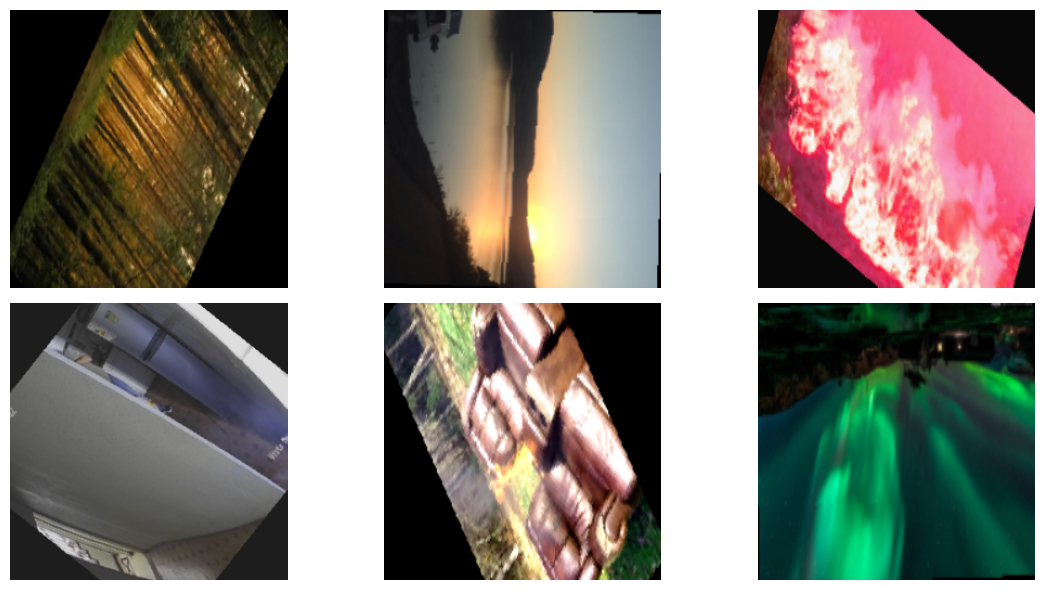

In [7]:
#1.6: Visualization
#We want to make sure it looks okay!
# Create a DataLoader to retrieve a small batch of images
sample_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

# Retrieve one batch of images and labels
images, labels = next(iter(sample_loader))

# Create a figure
plt.figure(figsize=(12, 6))

# Display six images
for i in range(6):

    plt.subplot(2, 3, i + 1)
    # Convert from (Channels, Height, Width) to (Height, Width, Channels)
    image = images[i].permute(1, 2, 0) # We do this because PyTorch stores images as channel x height x width
    print(np.max(image.cpu().numpy()))
    plt.imshow(image)
    # Hide the axes
    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 2: Splitting dataset

In [8]:
## STEP 2: Splitting dataset into Testing, Training, and Validation ##
#2.0: variables needed

train_factor=0.7
val_factor=0.15

batch_size = 128 #training batches

In [9]:
#2.3: Dataloaders

# Create DataLoaders
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
validation_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [10]:
#2.4: Verify loaders
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Testing batches:    {len(test_loader)}")

images, labels = next(iter(train_loader)) #check loaders
print(images.shape)
print(labels.shape)

Training batches:   17
Validation batches: 4
Testing batches:    4
torch.Size([128, 3, 256, 256])
torch.Size([128])


STEP 3: Network Design

In [11]:
##STEP 3: Network Design##
#3.0: Variables needed
lr=0.001

In [12]:
#3.2: Create model
model = architecture.SimpleCNN()
model.load_state_dict(torch.load("highres.pth"))
model = model.to("mps")
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=262144, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [13]:
print(len(list(model.parameters())))

14


In [14]:
#3.3: Optimizer and loss function
# Define the loss function
criterion = nn.BCEWithLogitsLoss() # use nn.CrossEntropyLoss() for multi-class. Also, the output activation is built into this function
#NOTE: the standard BCE function does not factor in sigmoid, so must add a sigmoid output if doing binary classification
#unless you use nn.BCEWithLogitsLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(),lr=lr)

STEP 4: Training

In [15]:
##Step 4: Training##
#4.0: Variables needed
num_epochs=10

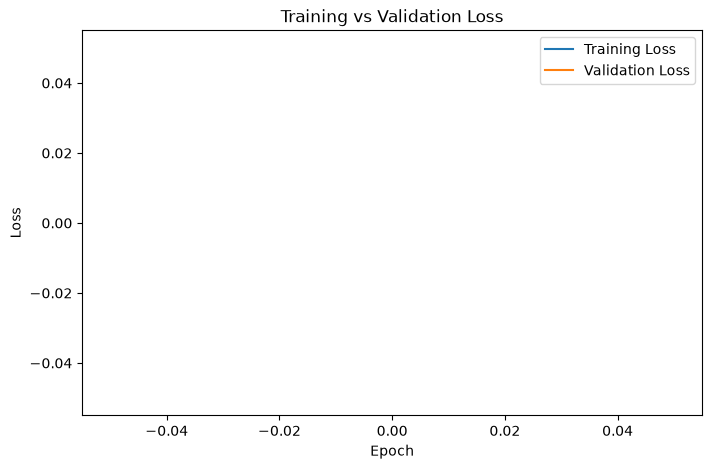

In [16]:
#4.1: Set up tracking vars
# Store performance history
train_losses = []
validation_losses = []
train_accuracies = []
validation_accuracies = []

#Set of val vs. train loss graph
# Create a figure for live loss tracking
plt.ion()  # Turn on interactive plotting
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")

train_loss_line, = ax.plot([],[],label="Training Loss")
validation_loss_line, = ax.plot([],[],label="Validation Loss")

ax.legend()
plt.show()

In [17]:
#4.2: Training Loop
for epoch in range(num_epochs):
    print("-" * 50)
    print(f"Epoch {epoch + 1}/{num_epochs}")
    model.train() #puts model in training mode

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in tqdm.tqdm(train_loader):

        # Move data to CPU or GPU
        images = images.to(device) #move data to selected device
        labels = labels.to(device).float().unsqueeze(1) #BCE expects decimal values. Remove .float() if doing multi-class

        # Clear previous gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Calculate loss
        loss = criterion(outputs, labels)
        # Backpropagation
        loss.backward()
        # Update model weights
        optimizer.step()
        # Add loss
        running_loss += loss.item()

        # Calculate probabilities
        probabilities = torch.sigmoid(outputs)
        predicted = (probabilities >= 0.5).float()
        # replace the above 2 lines with:
        #_, predicted = torch.max(outputs, 1)
        #if doing multi class

        # Count correct predictions
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()


    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = (correct_predictions /total_predictions) * 100
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Training Loss: {epoch_loss:.4f}")
    print(f"Training Accuracy: {epoch_accuracy:.2f}%")

    model.eval()
    validation_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for images, labels in tqdm.tqdm(validation_loader):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            outputs = model(images)

            loss = criterion(outputs,labels)
            validation_loss += loss.item()
            probabilities = torch.sigmoid(outputs)
            predicted = (probabilities >= 0.5).float()
            #"_, predicted = torch.max(outputs,1)" replaces above two lines if multiclass

            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    validation_loss /= len(validation_loader)

    validation_accuracy = (correct_predictions / total_predictions) * 100

    validation_losses.append(validation_loss)
    validation_accuracies.append(validation_accuracy)

    print(f"Validation Loss: {validation_loss:.4f}")
    print(f"Validation Accuracy: {validation_accuracy:.2f}%")

    # Update loss plot
    train_loss_line.set_data(range(1, len(train_losses) + 1),train_losses)
    validation_loss_line.set_data(range(1, len(validation_losses) + 1),validation_losses)

    # Adjust graph limitsF
    ax.relim()
    ax.autoscale_view()

    # Redraw graph
    fig.canvas.draw()
    fig.canvas.flush_events()

    if evaluate.mainloop() > 0.925:
        break

--------------------------------------------------
Epoch 1/10


100%|██████████| 17/17 [00:29<00:00,  1.71s/it]


Training Loss: 0.3988
Training Accuracy: 84.68%


100%|██████████| 4/4 [00:06<00:00,  1.74s/it]


Validation Loss: 0.3597
Validation Accuracy: 85.84%


...

100%|██████████| 17/17 [00:31<00:00,  1.83s/it]


Training Loss: 0.2426
Training Accuracy: 90.12%


100%|██████████| 4/4 [00:07<00:00,  1.87s/it]


Validation Loss: 0.2395
Validation Accuracy: 90.77%


100%|██████████| 4/4 [00:06<00:00,  1.57s/it]


STEP 5: Training and loading a CNN

In [18]:
#5.0: Variables
CNN_path='finetuned.pth'

In [19]:
#5.1: Saving CNN
# Save the trained model parameters
torch.save(model.state_dict(),CNN_path)

print("Model saved successfully!")

Model saved successfully!


In [20]:
#5.2: Loading CNN

#load empty model
loaded_model = architecture.SimpleCNN() #put num_classes = num_classes in parentheses if multiclass

# Load the saved parameters
loaded_model.load_state_dict(torch.load(CNN_path))

#Load model to device
loaded_model = loaded_model.to(device)

#Ensure model is in evaluation mode
loaded_model.eval()

#Test to see if it works
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = loaded_model(images)
    probabilities = torch.sigmoid(outputs)
    predictions = (probabilities >= 0.5).float()

#Gives logits vs. probs vs. predictions for educational purposes
print("Logits:")
print(outputs.squeeze())

print("\nProbabilities:")
print(probabilities.squeeze())

print("\nPredictions:")
print(predictions.squeeze())


Logits:
tensor([ -2.9834,  -0.8083,  -1.0315,   1.9063,  -3.1213,  -5.4767,  -3.5282,
         -5.8220,  -6.0707,  -5.5592,  -2.5758,  -3.2049,  -6.5785,  -0.5020,
         -3.5100,  -3.2726,  -2.7786,  -5.5606,  -0.7309,  -4.8144,  -4.0791,
        -11.4904,  -0.7409,  -2.5681,  -9.0415,  -2.8735,  -5.7291,  -4.1907,
         -1.5468,  -4.0219,  -5.8752,  -4.1308,  -1.8510,  -2.1241,  -2.5340,
         -0.6453,  -0.9118,  -1.5684,  -4.8058,  -3.0405,  -1.7019,  -2.6568,
         -8.4592,  -4.2455,  -1.6545,  -4.4120,  -4.3610,  -8.9627,  -7.3802,
         -3.0135,  -1.7510,  -3.7833,  -5.3330,  -6.3302,  -7.4443,  -2.5621,
         -1.2107,  -4.1149,  -3.6277,  -3.6702,  -4.9784,  -1.0520,  -7.7942,
         -4.0635,  -3.4794,  -7.2297,  -6.2419,  -4.9457,  -3.8021,  -4.0765,
         -0.0436,  -2.7377,  -1.0761,  -3.2263,  -3.2641, -11.2267,  -3.7184,
         -4.6410,  -0.3266,  -5.2468,  -3.7242,  -1.0621,  -1.4040,   7.3733,
         -6.6580,  -5.2007,  -7.2898,   1.0425,  -1.9068

STEP 6: Model Evaluation

In [21]:
#Ensure model has already been loaded using 5.2


In [22]:
#6.1: Predictions on test set
# Store predictions and true labels
all_predictions = []
all_labels = []

# Disable gradient calculations
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        print(labels.shape)

        # Get model outputs
        outputs = model(images)

        # Convert outputs into class predictions

        probabilities = torch.sigmoid(outputs)
        predicted = (probabilities >= 0.5).float()
        print(predicted.shape)
        #"_, predictions = torch.max(outputs,1)" replaces above two lines if multi-class

        # Store results
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

torch.Size([128])
torch.Size([128, 1])
torch.Size([128])
torch.Size([128, 1])
torch.Size([128])
torch.Size([128, 1])
torch.Size([90])
torch.Size([90, 1])


In [23]:
#6.2: Test Accuracy
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels,all_predictions)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 90.93%


In [24]:
#6.3: Classification Report
#gives precision, recall, and F1
print(classification_report(all_labels,all_predictions))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       222
           1       0.93      0.89      0.91       252

    accuracy                           0.91       474
   macro avg       0.91      0.91      0.91       474
weighted avg       0.91      0.91      0.91       474



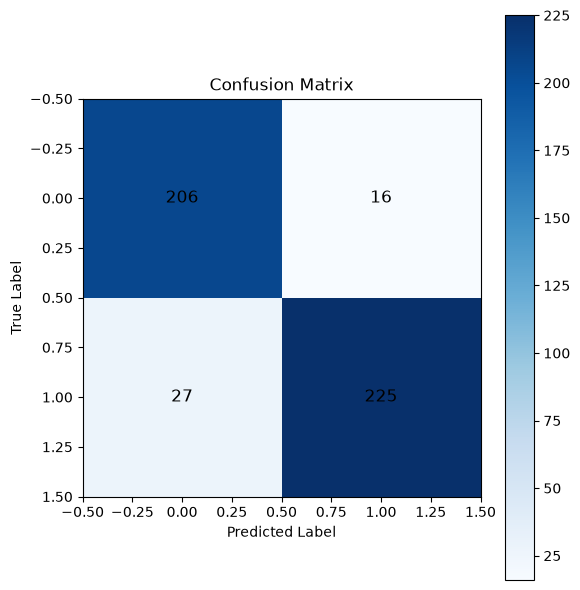

In [25]:
#6.4: Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")


# Display the counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,str(cm[i, j]),ha="center",va="center",color="black",fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()

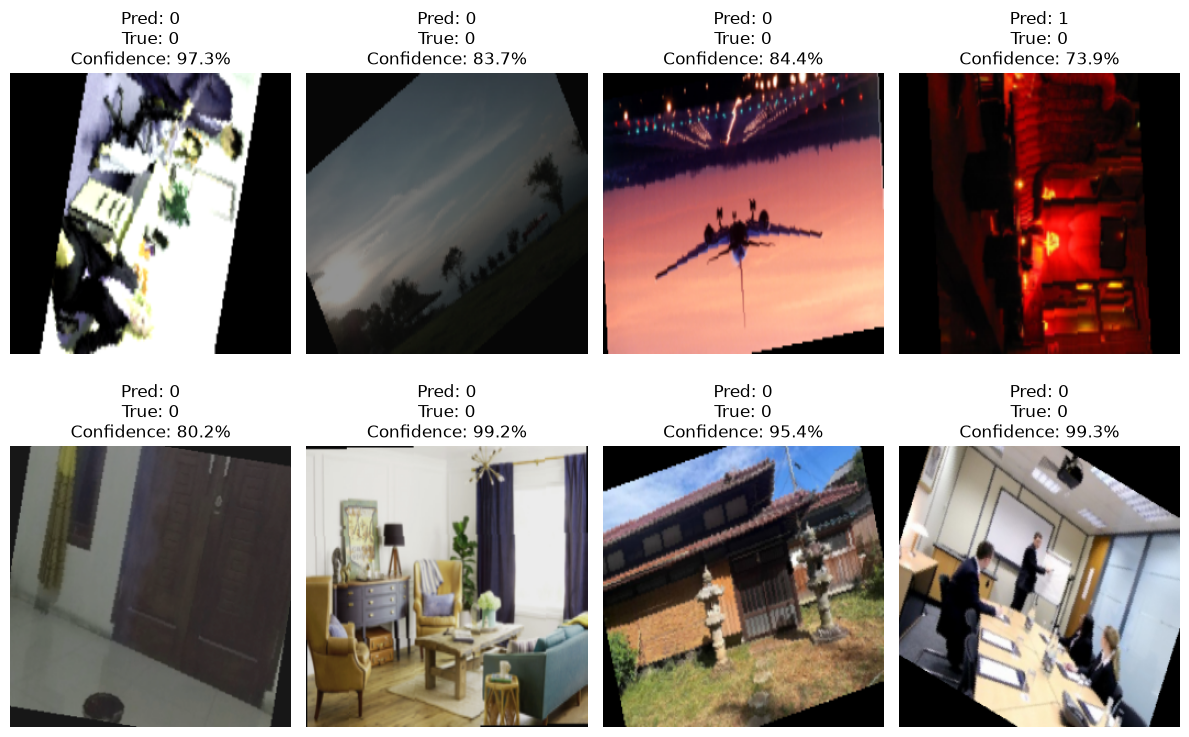

In [26]:
# 6.5: Display examples with confidence
images, labels = next(iter(test_loader))
images = images.to(device)

# Make predictions
with torch.no_grad():
    outputs = model(images)
    # Convert logits to probabilities
    probabilities = torch.sigmoid(outputs) #replace with "torch.softmax(outputs,dim=1)" if multi-class
    # Get predicted class and confidence
    predictions = (probabilities >= 0.5).float()
    #replace above line with "confidence, predictions = torch.max(probabilities,dim=1)" if multi-class

#Format properly (only for binary)
probabilities = probabilities.squeeze()
predictions = predictions.squeeze()

# Move data back to CPU for plotting
images = images.cpu()
predictions = predictions.cpu()
confidence = probabilities.cpu()
labels = labels.cpu()
plt.figure(figsize=(12, 8))


for i in range(8):

    plt.subplot(2, 4, i + 1)

    # Change image from (channels, height, width)
    # to (height, width, channels)
    image = images[i].permute(1,2,0)

    plt.imshow(image)

    predicted_class = int(predictions[i].item())
    actual_class = int(labels[i].item())

    confidence = probabilities[i].item()
    # If prediction is class 0, flip confidence
    # because sigmoid gives probability of class 1
    if predictions[i] == 0:
        confidence = 1 - confidence
    confidence_percent = confidence * 100

    plt.title(
        f"Pred: {predicted_class}\n"
        f"True: {actual_class}\n"
        f"Confidence: {confidence_percent:.1f}%")

    plt.axis("off")

plt.tight_layout()
plt.show()


In [27]:
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

33624289
